# Toxic Comments Classification - LR

#### Author: SAFAA ENNACIRI - ENNS11538307                                 
#### Research Director: M. HAKIM LOUNIS

Dataset: JgsawToxic dataset is a dataset of comments from Wikipedia’s talk page edits. It is avaialble at Kaggle (https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge/data). 


The comments are divided in two classes: toxic and normal.

Algorithme used: LR

Preprocessing techniques used:
* Convert text to lowercase
* Stemming
* Tokenization (accept all kind of tokens except spaces (returns, line breaks, tabs and multiple spaces))

# 1. Importing Libraries

In [1]:
import sys
sys.getrecursionlimit()

3000

In [2]:
sys.setrecursionlimit(5000)
sys.getrecursionlimit()

5000

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn import metrics
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, cross_val_predict
from matplotlib import pyplot as plt 
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import pickle
import openpyxl 
from openpyxl import Workbook
from openpyxl.styles import Alignment
from openpyxl.styles.borders import Border, Side
import nltk
from nltk.stem import PorterStemmer

# 2. Data Preparation 

In [4]:
# Load training data
df = pd.read_csv('../../Data/train_set2.csv')
df.head()

,Unnamed: 0,tweet,tox
0,12478,Just straight like that. No chaser. And the bi...,1
1,5791,@blowme you mean trash.,0
2,589,"""WHAAAAAAT! LMAOOO!!! @Cromotoasted: @creepgod...",1
3,18302,RT @Tylar____: Man this hoe Heaven stay taking...,1
4,8736,"Col. Sanders, Part 2: ""...and those sons of bi...",1


In [5]:
# Load testing data
test = pd.read_csv('../../Data/test_set2.csv')
test.head()

,Unnamed: 0,tweet,tox
0,24082,auto tranny,0
1,10605,I get gwop now that bitch remember me,1
2,15645,RT @FunnyPicsDepot: Niggas develop superpowers...,1
3,6551,@kaylonnnnn then who are you to call me trash ...,0
4,14482,RT @AliAbunimah: The people of the ghetto are ...,0


# 3. Preprocessing

In [6]:
stemmer = PorterStemmer()

def stemming_token (comment):     
    for word in comment.split():
        comment = comment.replace(word, stemmer.stem(word)) # Converting words to their root forms
    return comment

In [7]:
def clean_text(comment): 

    comment = comment.lower() # Normalize to lowercase 
    stem_comment = stemming_token (comment) # stemming comment
    
    return stem_comment

In [8]:
# clean and normalize comments
df['tweet'] = df['tweet'].map(lambda word:clean_text(word))
test['tweet'] = test['tweet'].map(lambda word:clean_text(word))

In [9]:
x_train = df['tweet']
y_train = df['tox']

#Check shape of data
print(x_train.shape)
print(y_train.shape)

(26521,)
(26521,)


In [10]:
X_test = test['tweet']
Y_test = test['tox']

#Check shape of data
print(X_test.shape)
print(Y_test.shape)

(6631,)
(6631,)


# 3. Classifier training (LR)

### Create pipeline

In [11]:
# create a pipeline
model_pipeline = Pipeline([
                ('tfidf', TfidfVectorizer(lowercase=False, 
                                          token_pattern=r'\S+', max_features=20000)),
                ('clf', LogisticRegression(max_iter=1000, random_state=0, verbose=True, C=10,
                                           class_weight='balanced', penalty='l1', solver='saga'))])

### Train classifier

In [12]:
# cross validation
metrics = ['accuracy', 'recall', 'f1', 'precision']
result = cross_validate (model_pipeline, x_train, y_train, cv=5, scoring = metrics,  return_estimator=True)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 594 epochs took 375 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 625 epochs took 391 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  6.0min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 532 epochs took 316 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 672 epochs took 309 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  5.2min finished


In [13]:
# save models
svc_fit = result['estimator']
i = 0
for model in svc_fit:
    dir_name = "models/Set1_approach#20_" + str(i) + ".sav"
    pickle.dump(model, open(dir_name, 'wb'))
    i = i + 1

### Evaluate metrics

In [14]:
# Model Evaluation metrics for train data
train_accuracy = "%.4f" % (result['test_accuracy'].mean())
train_recall  = "%.4f" % (result['test_recall'].mean())
train_F1_score  = "%.4f" % (result['test_f1'].mean())
train_precision  = "%.4f" % (result['test_precision'].mean())

# Print scores for evaluation metrics
print('Results for train data')
print ('-----------------------')
print('Accuracy score : ', train_accuracy)
print('recall : ', train_recall)
print('F1_score : ' , train_F1_score)
print('precision : ' , train_precision)

Results for train data
-----------------------
Accuracy score :  0.9642
recall :  0.9322
F1_score :  0.9629
precision :  0.9957


# 4. Predictions

### Test set

In [15]:
# predict test data
preds_test = cross_val_predict(model_pipeline, X_test, Y_test, cv=5)

[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 512 epochs took 28 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   28.4s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 503 epochs took 30 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   30.1s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


...

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   27.1s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 373 epochs took 23 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   23.1s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.


convergence after 687 epochs took 39 seconds


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   38.9s finished


In [16]:
# svm Confusion matrix
print('\n confusion matrix for test data \n')
print((confusion_matrix(Y_test, preds_test)))


 confusion matrix for test data 

[[3242  111]
 [ 335 2943]]


In [17]:
# svm classification report
print('\n\n classification report for test data \n')
print(classification_report(Y_test, preds_test, target_names=['normal','toxic']))



 classification report for test data 

              precision    recall  f1-score   support

      normal       0.91      0.97      0.94      3353
       toxic       0.96      0.90      0.93      3278

    accuracy                           0.93      6631
   macro avg       0.94      0.93      0.93      6631
weighted avg       0.93      0.93      0.93      6631



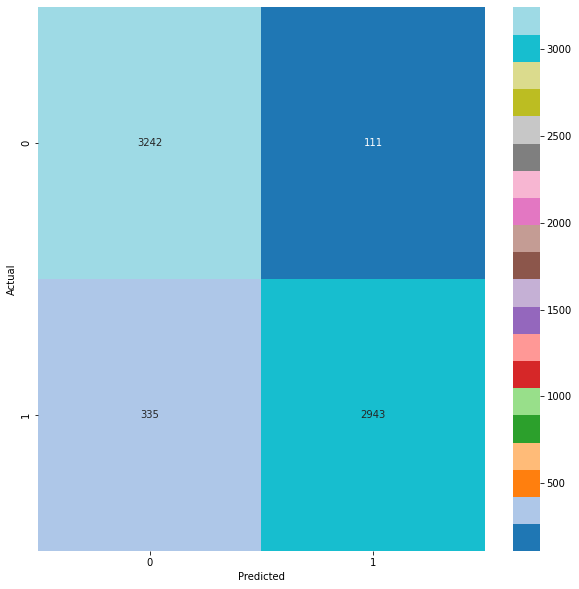

In [18]:
# plot confusion matrix
conf_mat = confusion_matrix(Y_test, preds_test)
fig, ax = plt.subplots(figsize=(10,10))
cmap = "tab20"
sns.heatmap(conf_mat, annot=True, fmt='d',cmap=cmap)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [19]:
# Model Evaluation metrics for test data
test_accuracy = "%.4f" % (accuracy_score(Y_test, preds_test))
test_recall  = "%.4f" % (recall_score(Y_test, preds_test))
test_F1_score  = "%.4f" % (f1_score(Y_test, preds_test))
test_precision  = "%.4f" % (precision_score(Y_test, preds_test))

# Print scores for evaluation metrics
print('Results for test data')
print ('-----------------------')
print('Accuracy score : ', test_accuracy)
print('recall : ', test_recall)
print('F1_score : ' , test_F1_score)
print('precision : ' , test_precision)

Results for test data
-----------------------
Accuracy score :  0.9327
recall :  0.8978
F1_score :  0.9296
precision :  0.9637


# 5. Save results to Excel file

In [20]:
# define tarjet
newFile = "../results_LR_set2.xlsx"

# open excel file
workbook = openpyxl.load_workbook(filename = newFile)        
worksheet = workbook.active
    
# scores for evaluation metrics
data = {1:'Approach #20', 2:train_accuracy, 3:train_recall, 4:train_F1_score, 5:train_precision, 
                  6:test_accuracy, 7:test_recall, 8:test_F1_score, 9:test_precision}

# row's index for approach
index = 22

# delete row of approach
worksheet.delete_rows(index, 1)

# insert data in excel sheet
worksheet.insert_rows(index)
for col, value in data.items():
    worksheet.cell(row=index, column=col, value=value)
    
# define style border
thin_border = Border(left=Side(style='thin'), 
                     right=Side(style='thin'), 
                     top=Side(style='thin'), 
                     bottom=Side(style='thin'))
cell_alignment = Alignment(horizontal='center')

# apply style border
for row in worksheet:
    for cell in row:
        cell.border = thin_border
        cell.alignment = cell_alignment
    
# save file
workbook.save(newFile)